In [3]:
import json
import os
import math
import random
import pandas as pd
from collections import defaultdict, Counter
from src.grammar.basic_generator import BasicGrammar
from src.grammar.controlled_generator import ControlledFSM
from src.grammar.utils import transition_entropy, estimate_entropy, estimate_valid_sample_difficulty#, estimate_diversity
from src.grammar.examples import GRAMMARS

In [4]:
fsms = {}
for gname, gjson in GRAMMARS.items():
    fsms[gname] = BasicGrammar.from_json(
        gjson, #.replace("\n", ""),
        is_path=False
    )
    print(gname, "loaded")
for gname in os.listdir("generated_grammars"):
    fsms[gname.split(".")[0]] = BasicGrammar.from_json(f"generated_grammars/{gname}", is_path=True)
    print(gname.split(".")[0], "loaded")

SIMPLE_LOOP_GRAMMAR loaded
ALTERNATING_AB_LOOP_GRAMMAR loaded
ALTERNATING_ABEXPONENT_LOOP_GRAMMAR loaded
ALTERNATING_CONSONANT_VOWEL_LOOP_GRAMMAR loaded
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR loaded
ALTERNATING_GIBBEGIBBERISH_LOOP_GRAMMAR loaded
ALTERNATING_GIBBEGIBBERISHEXPONENT_LOOP_GRAMMAR loaded
LADDER_GRAMMAR loaded
WAYBACK_GRAMMAR loaded
ALTERNATING_MUSTSTOP_LOOP_GRAMMAR loaded
ALTERNATING_MUSTSTOPEXPONENT_LOOP_GRAMMAR loaded
WAYBACK_WORD_GRAMMAR loaded
s11_a3 loaded
s13_a10 loaded
s3_a3 loaded
s3_a4 loaded
s4_a2 loaded
s4_a4 loaded
s4_a6 loaded
s4_a8 loaded
s5_a4 loaded
s5_a5 loaded
s5_a5bis loaded
s6_a4 loaded
s7_a3 loaded
s7_a7 loaded
s9_a9 loaded


In [5]:
NUM_ITERATIONS_MOST_GRAMMARS = 2
to_keep = {
    "ALTERNATING_ABEXPONENT_LOOP_GRAMMAR": 1,
    "ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR": 1,
    "LADDER_GRAMMAR": NUM_ITERATIONS_MOST_GRAMMARS,
    "WAYBACK_GRAMMAR": NUM_ITERATIONS_MOST_GRAMMARS,
    #"ALTERNATING_MUSTSTOPEXPONENT_LOOP_GRAMMAR": 1,
    #"WAYBACK_WORD_GRAMMAR": NUM_ITERATIONS_MOST_GRAMMARS,
    "s11_a3": NUM_ITERATIONS_MOST_GRAMMARS,
    "s13_a10": NUM_ITERATIONS_MOST_GRAMMARS,
    "s3_a3": NUM_ITERATIONS_MOST_GRAMMARS,
    "s3_a4": NUM_ITERATIONS_MOST_GRAMMARS,
    "s4_a2": NUM_ITERATIONS_MOST_GRAMMARS,
    "s4_a4": NUM_ITERATIONS_MOST_GRAMMARS,
    "s4_a8": NUM_ITERATIONS_MOST_GRAMMARS,
    "s5_a4": NUM_ITERATIONS_MOST_GRAMMARS,
    "s5_a5": NUM_ITERATIONS_MOST_GRAMMARS,
    "s5_a5bis": NUM_ITERATIONS_MOST_GRAMMARS,
    "s6_a4": NUM_ITERATIONS_MOST_GRAMMARS,
    "s7_a3": NUM_ITERATIONS_MOST_GRAMMARS,
    "s7_a7": NUM_ITERATIONS_MOST_GRAMMARS,
    "s9_a9": NUM_ITERATIONS_MOST_GRAMMARS,
}

In [6]:
# for k in to_keep:
#     print(k, "".join(fsms[k]._compute_effective_alphabet()))

In [7]:
print("Number of grammars:", len(to_keep))
print("Number of datasets:", sum(to_keep.values()))

Number of grammars: 18
Number of datasets: 34


In [10]:
DIFFICULTIES = {}
max_len_v = 6
for fsmname in to_keep:
    fsm = fsms[fsmname]
    print(fsmname)
    #norm_den = (len(fsm._compute_effective_alphabet()) ** max_len_v)
    DIFFICULTIES[fsmname] = 0.5*(abs(transition_entropy(fsm)) + abs(estimate_entropy(fsm)))# +\
    #math.log(norm_den) * len(fsm.enumerate_valid_samples(max_len=max_len_v))/norm_den

ALTERNATING_ABEXPONENT_LOOP_GRAMMAR
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR
LADDER_GRAMMAR
WAYBACK_GRAMMAR
s11_a3
s13_a10
s3_a3
s3_a4
s4_a2
s4_a4
s4_a8
s5_a4
s5_a5
s5_a5bis
s6_a4
s7_a3
s7_a7
s9_a9


In [11]:
for fsmname, difficulty in sorted(DIFFICULTIES.items(), key=lambda x: x[1]):
    print(fsmname, difficulty)

s3_a3 0.20216736679585373
s3_a4 0.21357886222442116
s5_a4 0.26963177887219303
ALTERNATING_ABEXPONENT_LOOP_GRAMMAR 0.2831705121134443
LADDER_GRAMMAR 0.2847909729860345
s4_a2 0.2870619008624506
s5_a5 0.3158938157452091
s4_a8 0.317472644762005
s7_a7 0.3221657714056029
s7_a3 0.41147957101650645
s11_a3 0.4716166954441086
s5_a5bis 0.4730614907381394
WAYBACK_GRAMMAR 0.4785479442448505
s4_a4 0.5003935367816964
s6_a4 0.5236532210538938
s13_a10 0.5773915057759849
s9_a9 0.6487603471206486
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR 1.4146346039369357


In [12]:
UPPER_LIMIT_VALID_SAMPLE_GENERATION = 1000
MAX_CHARS = 50
first_valid_samples = {}
for fsmname in fsms.keys():
    first_valid_samples[fsmname] = fsms[fsmname].enumerate_valid_samples(
            max_len=MAX_CHARS,
            early_stop_function=lambda x: len(x) > UPPER_LIMIT_VALID_SAMPLE_GENERATION
        )
    first_valid_samples[fsmname] = [s for s in first_valid_samples[fsmname] if s]

In [13]:
MAX_NUMBER_INVALID = 300
first_invalid_samples = defaultdict(set)
difficulty_invalid = defaultdict(dict)
for fsmname in to_keep.keys():
    print(fsmname)
    original_alphabet = fsms[fsmname].alphabet
    # if len(original_alphabet) < 3:
    #     fsms[fsmname].alphabet = list(set(fsms[fsmname].alphabet).union({"a","b","c"}))
    while len(first_invalid_samples[fsmname]) < MAX_NUMBER_INVALID:
        ret = fsms[fsmname].generate_plausible_invalid(
            expected_len=(el:=random.randint(1, MAX_CHARS)), num_disruptions_range=(1, random.randint(1, max(1, el//2))))
        if ret is None: continue
        invalid_sample, num_disruptions = ret
        first_invalid_samples[fsmname].add(invalid_sample)
        difficulty_invalid[fsmname][invalid_sample] = 1 - num_disruptions / len(invalid_sample)
    first_invalid_samples[fsmname] = sorted(first_invalid_samples[fsmname], key=lambda x: len(x))
    fsms[fsmname].alphabet = original_alphabet

ALTERNATING_ABEXPONENT_LOOP_GRAMMAR
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR
LADDER_GRAMMAR
WAYBACK_GRAMMAR
s11_a3
s13_a10
s3_a3
s3_a4
s4_a2
s4_a4
s4_a8
s5_a4
s5_a5
s5_a5bis
s6_a4
s7_a3
s7_a7
s9_a9


In [15]:
# sanity checks
for k, v in first_valid_samples.items():
    if k not in to_keep.keys():
        continue
    for w in v:
        if not fsms[k].is_valid(w):
            print(f"Error: {w} should be valid for {k}")
for k, v in first_invalid_samples.items():
    if k not in to_keep.keys():
        continue
    for w in v:
        if fsms[k].is_valid(w):
            print(f"Error: {w} should be invalid for {k}")

In [8]:
# len(first_valid_samples["ALTERNATING_ABEXPONENT_LOOP_GRAMMAR"])

In [9]:
# first_valid_samples.keys()

In [10]:
# Counter([len(word) for word in first_valid_samples["s6_a4"]])

In [ ]:
# Number of valid examples generated for each grammar kept
{k: len(v) for k, v in first_valid_samples.items() if k in to_keep}

{'ALTERNATING_ABEXPONENT_LOOP_GRAMMAR': 1001,
 'ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR': 1001,
 'LADDER_GRAMMAR': 1001,
 'WAYBACK_GRAMMAR': 1001,
 's11_a3': 1001,
 's13_a10': 1000,
 's3_a3': 1001,
 's3_a4': 1000,
 's4_a2': 1001,
 's4_a4': 1001,
 's4_a8': 1000,
 's5_a4': 1001,
 's5_a5': 1001,
 's5_a5bis': 1001,
 's6_a4': 1001,
 's7_a3': 1001,
 's7_a7': 1000,
 's9_a9': 1001}

In [20]:
#{k: len(v) for k, v in first_invalid_samples.items() if k in to_keep}

In [21]:
df_data = []
columns = [
    "training_valid_samples",
    "training_invalid_samples",
    "inference_samples_labels_difficulty",
    "grammar",
    "grammar_name",
]
MIN_NUM_TRAININGS_VALID = 7 # before: 20
MAX_NUM_TRAININGS_VALID = 75 # before: 100
MIN_NUM_TRAININGS_INVALID = 3 # before: 10
NUM_INFERENCE_SAMPLES = 200
for fsmname, num_datasets in to_keep.items():
    print(fsmname)
    fsm = fsms[fsmname]
    for _ in range(num_datasets):
        num_trainings_valid = random.randint(MIN_NUM_TRAININGS_VALID, MAX_NUM_TRAININGS_VALID)
        num_trainings_invalid = random.randint(MIN_NUM_TRAININGS_INVALID, int(num_trainings_valid * 0.75))
        num_inference_valid = random.randint(0, NUM_INFERENCE_SAMPLES)
        trainings_valid_samples = random.choices(
            first_valid_samples[fsmname],
            weights=[1/len(s) for s in first_valid_samples[fsmname]], # must have made sure no empty string
            k=num_trainings_valid
        )
        trainings_valid_samples = sorted(trainings_valid_samples, key=lambda x: len(x))
        trainings_invalid_samples = random.choices(
            first_invalid_samples[fsmname],
            weights=[1/len(s) for s in first_invalid_samples[fsmname]], # must have made sure no empty string
            k=num_trainings_invalid
        )
        trainings_invalid_samples = sorted(trainings_invalid_samples, key=lambda x: len(x))
        inference_valid_samples = random.choices(
            [s for s in first_valid_samples[fsmname] if s not in trainings_valid_samples],
            weights=[1/len(s) for s in first_valid_samples[fsmname] if s not in trainings_valid_samples], # must have made sure no empty string
            k=num_inference_valid
        )
        inference_invalid_samples = random.choices(
            [s for s in first_invalid_samples[fsmname] if s not in trainings_invalid_samples],
            weights=[1/len(s) for s in first_invalid_samples[fsmname] if s not in trainings_invalid_samples], # must have made sure no empty string
            k=NUM_INFERENCE_SAMPLES - num_inference_valid
        )
        inference_samples = [[s, True] for s in inference_valid_samples] + [[s, False] for s in inference_invalid_samples]
        for isample in inference_samples:
            if isample[1]:
                isample.append(estimate_valid_sample_difficulty(isample[0], fsm, trainings_valid_samples))
            else:
                isample.append(difficulty_invalid[fsmname][isample[0]])
        random.shuffle(inference_samples)
        df_data.append(
            {
                "training_valid_samples": json.dumps(trainings_valid_samples),
                "training_invalid_samples": json.dumps(trainings_invalid_samples),
                "inference_samples_labels_difficulty": json.dumps(inference_samples),
                "grammar": fsm.to_jsondumps(),
                "grammar_name": fsmname,
            }
        )

ALTERNATING_ABEXPONENT_LOOP_GRAMMAR
ALTERNATING_CONSONANT_VOWELEXPONENT_LOOP_GRAMMAR
LADDER_GRAMMAR
WAYBACK_GRAMMAR
s11_a3
s13_a10
s3_a3
s3_a4
s4_a2
s4_a4
s4_a8
s5_a4
s5_a5
s5_a5bis
s6_a4
s7_a3
s7_a7
s9_a9


In [22]:
df = pd.DataFrame(df_data, columns=columns)

In [23]:
len(df)

34

In [24]:
df.to_csv("generated_datasets/artificial_grammars_medlight_balanced_inference200_betteralpha_less_training.csv", index=None)

In [25]:
df.to_excel("generated_datasets/artificial_grammars_medlight_balanced_inference200_betteralpha_less_training.xlsx", index=None)

In [26]:
df.inference_samples_labels_difficulty.apply(json.loads).apply(len).value_counts()

inference_samples_labels_difficulty
200    34
Name: count, dtype: int64

<Axes: >

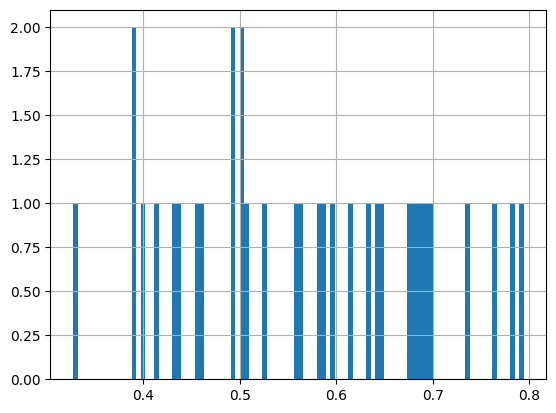

In [ ]:
# plotting a histogram of estimated average difficulty for each inference set
df.inference_samples_labels_difficulty.apply(json.loads).apply(lambda x: sum([y[2] for y in x])/len(x)).hist(bins=100)